In [118]:
import pandas as pd


df = pd.read_parquet(
    "../../data/analytical/base_analitica_v1.parquet"
)

df.head()

,id_municipio,Municipio,UF,Capital,taxa_alfabetizacao_2023,percentual_participacao_2023,meta_alfabetizacao_2024,taxa_alfabetizacao_2024,Regiao,gap_meta_2024,target_atingiu_meta_2024
0,4301750,Barão do Triunfo,RS,Falso,NaN,NaN,NaN,4.40,Sul,NaN,0
1,2406908,Lucrécia,RN,Falso,4.4,82.14,7.94,42.86,Nordeste,3.54,1
2,1718501,Recursolândia,TO,Falso,4.6,95.65,8.25,50.29,Norte,3.65,1
3,2919900,Macururé,BA,Falso,4.7,87.76,8.39,12.50,Nordeste,3.69,1
4,2414456,Triunfo Potiguar,RN,Falso,NaN,NaN,NaN,10.95,Nordeste,NaN,0


In [119]:
df_censo = pd.read_csv(
    "../../data/dados_populacao/censo_2022.csv"
)

df_censo.head()

,id_municipio,id_municipio_nome,domicilios,taxa_alfabetizacao,indice_envelhecimento,idade_mediana,razao_sexo
0,1400704,Uiramutã,2339,0.87529,5.40,15.0,105.76
1,1200435,Santa Rosa do Purus,1344,0.77397,7.68,17.0,103.73
2,1400407,Normandia,2719,0.91823,8.23,17.0,106.53
3,1200328,Jordão,2003,0.81876,6.55,18.0,107.10
4,1303908,São Paulo de Olivença,6010,0.85195,11.12,19.0,105.88


In [120]:
df_censo = df_censo[
    [
        "id_municipio",
        "domicilios",
        "taxa_alfabetizacao",
        "indice_envelhecimento",
        "idade_mediana",
        "razao_sexo"
    ]
].copy()

In [121]:
df_censo = df_censo.rename(
    columns={
        "taxa_alfabetizacao":
            "taxa_alfabetizacao_censo_2022",
        "domicilios":
            "domicilios_2022",
        "indice_envelhecimento":
            "indice_envelhecimento_2022",
        "idade_mediana":
            "idade_mediana_2022",
        "razao_sexo":
            "razao_sexo_2022"
    }
)

In [122]:
df_modelo = df.dropna(subset=[
    "taxa_alfabetizacao_2023",
    "percentual_participacao_2023",
    "meta_alfabetizacao_2024",
    "taxa_alfabetizacao_2024"
]).copy()

In [123]:
df_modelo["id_municipio"] = (
    df["id_municipio"]
    .astype(str)
)

df_censo["id_municipio"] = (
    df_censo["id_municipio"]
    .astype(str)
)


df_v4 = df_modelo.merge(
    df_censo,
    on="id_municipio",
    how="left",
    validate="one_to_one"
)

print("Base V4:", df_v4.shape)

Base V4: (5232, 16)


In [124]:
df_v4.head()

,id_municipio,Municipio,UF,Capital,taxa_alfabetizacao_2023,percentual_participacao_2023,meta_alfabetizacao_2024,taxa_alfabetizacao_2024,Regiao,gap_meta_2024,target_atingiu_meta_2024,domicilios_2022,taxa_alfabetizacao_censo_2022,indice_envelhecimento_2022,idade_mediana_2022,razao_sexo_2022
0,2406908,Lucrécia,RN,Falso,4.4,82.14,7.94,42.86,Nordeste,3.54,1,1200,0.82493,68.93,36.0,97.62
1,1718501,Recursolândia,TO,Falso,4.6,95.65,8.25,50.29,Norte,3.65,1,1043,0.78458,34.25,30.0,131.62
2,2919900,Macururé,BA,Falso,4.7,87.76,8.39,12.50,Nordeste,3.69,1,2436,0.77873,54.30,33.0,100.06
3,1716307,Pau D'Arco,TO,Falso,6.5,82.69,11.05,37.96,Norte,4.55,1,1372,0.86379,36.70,32.0,109.81
4,2205581,Lagoa do Piauí,PI,Falso,7.2,91.23,11.95,44.87,Nordeste,4.75,1,1591,0.82261,47.75,33.0,104.51


In [125]:
features = [
    "taxa_alfabetizacao_2023",
    "percentual_participacao_2023",
    "meta_alfabetizacao_2024",
    "domicilios_2022",
    "taxa_alfabetizacao_censo_2022",
    "indice_envelhecimento_2022",
    "idade_mediana_2022",
    "razao_sexo_2022",
    "Capital",
    "UF"
]

target = "taxa_alfabetizacao_2024"

X = df_v4[features]
y = df_v4["taxa_alfabetizacao_2024"]


In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [126]:
numeric_features = [
    "taxa_alfabetizacao_2023",
    "percentual_participacao_2023",
    "meta_alfabetizacao_2024",
    "domicilios_2022",
    "taxa_alfabetizacao_censo_2022",
    "indice_envelhecimento_2022",
    "idade_mediana_2022",
    "razao_sexo_2022",
]

categorical_features = [
    "Capital",
    "UF"
]

In [127]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor= ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [128]:
from sklearn.linear_model import LinearRegression

modelo_linear = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [129]:
modelo_linear.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['taxa_alfabetizacao_2023','percentual_participacao_2023', 'meta_alfabetizacao_2024',...,'UF','Capital','Regiao']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatica

In [130]:
y_pred_linear = modelo_linear.predict(X_test)

In [131]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

rmse_linear = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print(f"MAE:  {mae_linear:.2f}")
print(f"RMSE: {rmse_linear:.2f}")
print(f"R²:   {r2_linear:.2f}")

MAE:  8.49
RMSE: 11.18
R²:   0.65


In [132]:
avaliacao = pd.DataFrame({
    "real": y_test,
    "previsto": y_pred_linear
})

avaliacao["erro"] = (
    avaliacao["real"] - avaliacao["previsto"]
)

avaliacao["erro_absoluto"] = (
    avaliacao["erro"].abs()
)

avaliacao.head(10)

,real,previsto,erro,erro_absoluto
240,39.30,35.398299,3.901701,3.901701
584,49.34,49.297792,0.042208,0.042208
2259,34.55,46.471490,-11.921490,11.921490
1420,64.82,68.131657,-3.311657,3.311657
1835,46.14,59.749267,-13.609267,13.609267
80,51.81,33.871657,17.938343,17.938343
3859,90.23,76.975467,13.254533,13.254533
952,55.72,55.960024,-0.240024,0.240024
4431,91.72,69.245673,22.474327,22.474327
1260,43.99,60.861180,-16.871180,16.871180


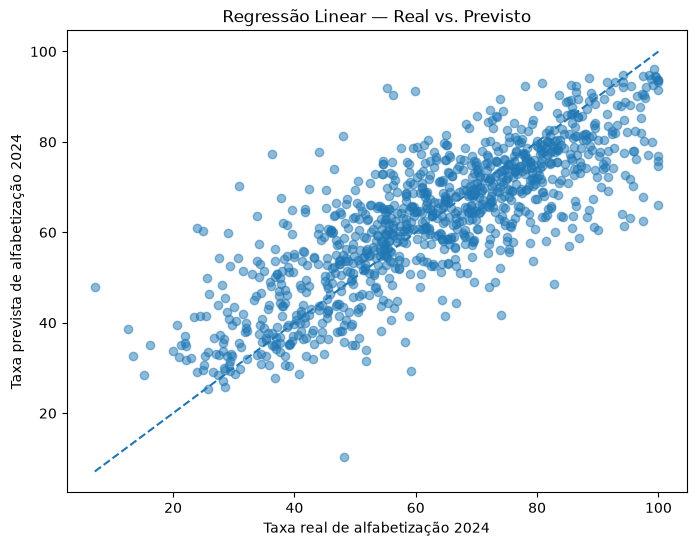

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    avaliacao["real"],
    avaliacao["previsto"],
    alpha=0.5
)

limite_min = min(
    avaliacao["real"].min(),
    avaliacao["previsto"].min()
)

limite_max = max(
    avaliacao["real"].max(),
    avaliacao["previsto"].max()
)

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle="--"
)

plt.xlabel("Taxa real de alfabetização 2024")
plt.ylabel("Taxa prevista de alfabetização 2024")
plt.title("Regressão Linear — Real vs. Previsto")

plt.show()

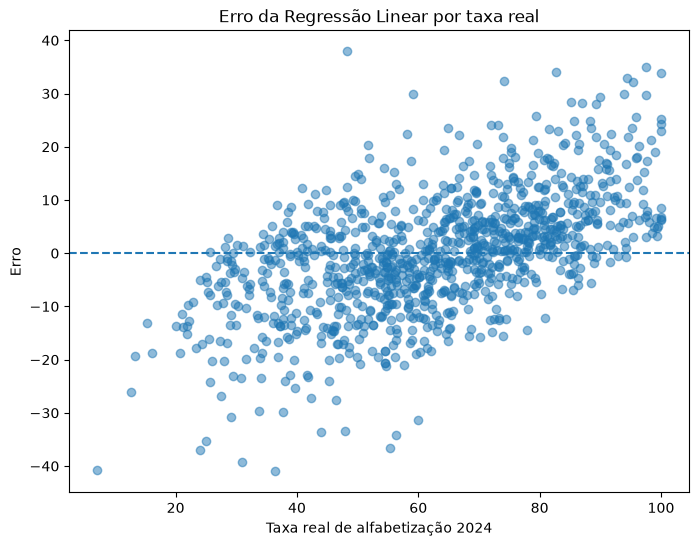

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(
    avaliacao["real"],
    avaliacao["erro"],
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Taxa real de alfabetização 2024")
plt.ylabel("Erro")
plt.title("Erro da Regressão Linear por taxa real")

plt.show()

In [63]:
import pandas as pd

# Recupera os nomes das features após o preprocessing
feature_names = modelo_linear.named_steps["preprocessor"].get_feature_names_out()

# Recupera os coeficientes da regressão
coefficients = modelo_linear.named_steps["model"].coef_

# Cria tabela
df_importance = pd.DataFrame({
    "variavel": feature_names,
    "coeficiente": coefficients
})

# Cria valor absoluto para ordenar pela magnitude
df_importance["peso_absoluto"] = (
    df_importance["coeficiente"].abs()
)

df_importance = df_importance.sort_values(
    "peso_absoluto",
    ascending=False
)

df_importance.head(20)

,variavel,coeficiente,peso_absoluto
29,cat__UF_RS,-18.240287,18.240287
13,cat__UF_CE,15.434489,15.434489
12,cat__UF_BA,-15.430938,15.430938
15,cat__UF_GO,11.492988,11.492988
31,cat__UF_SE,-10.481292,10.481292
14,cat__UF_ES,9.314775,9.314775
17,cat__UF_MG,9.027276,9.027276
26,cat__UF_RN,-8.539424,8.539424
0,num__taxa_alfabetizacao_2023,7.911305,7.911305
8,cat__UF_AC,-7.517769,7.517769
